# Wave-2 retraining + gen-4 data-appropriateness audit — exploration

**Thesis:** wave-1 gen-4 models failed UT→T (median 175–224 mm vs the production
polynomial's 11 µm) not from network capacity but from **data weighting + an
untamed 9.9-decade target range + under-training**. This notebook reproduces the
audit, documents the fixes (residual/kick head, range-aware loss, restratified
deployment-weighted corpus, tuned schedule, capacity ladder), and re-judges with
the three-arm evaluation.

In [1]:
import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
LAB = Path("/data/bfys/gscriven/TrackExtrapolation/experiments/gen_3")
DATA, TM, REF = LAB/"data", LAB/"trained_models", LAB/"paper_p0"
plt.rcParams['figure.dpi']=110

## 1 · Gen-4 appropriateness audit (the *why*)

UT->T fraction      : 0.145%   (13,349 tracks)
|dz|<1m / >6m       : 65.1% / 4.5%


x-bend |rx| decades : 8.5  (median 115 um, p99.9 3214 mm)


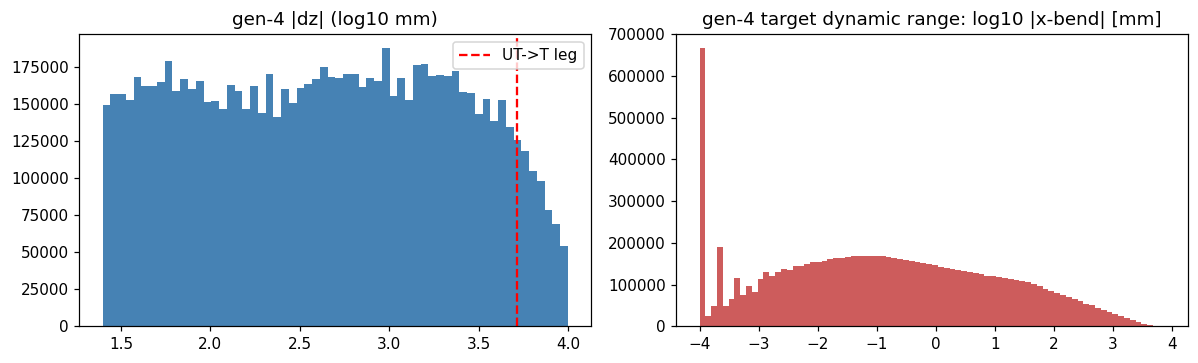

In [2]:
g = np.load(DATA/"train_10M_gen4.npz")
Xg, Yg = g["X"], g["Y"]
z0,dz = Xg[:,5], Xg[:,6]; zf=z0+dz
utt = (z0>=2300)&(z0<=3000)&(zf>=7600)&(zf<=9500)&(dz>0)
p = 0.299792458/np.abs(Xg[:,4])
rx = np.abs(Yg[:,0]-(Xg[:,0]+Xg[:,2]*dz))     # x-bend vs straight line [mm]
print(f"UT->T fraction      : {100*utt.mean():.3f}%   ({utt.sum():,} tracks)")
print(f"|dz|<1m / >6m       : {100*(np.abs(dz)<1000).mean():.1f}% / {100*(np.abs(dz)>6000).mean():.1f}%")
print(f"x-bend |rx| decades : {np.log10(np.quantile(rx[rx>0],0.999)/max(np.quantile(rx[rx>0],1e-3),1e-6)):.1f}"
      f"  (median {1e3*np.median(rx):.0f} um, p99.9 {np.quantile(rx,0.999):.0f} mm)")
fig,ax=plt.subplots(1,2,figsize=(11,3.4))
ax[0].hist(np.log10(np.abs(dz)),bins=60,color='steelblue'); ax[0].set_title("gen-4 |dz| (log10 mm)")
ax[0].axvline(np.log10(5161),color='r',ls='--',label='UT->T leg'); ax[0].legend()
ax[1].hist(np.log10(np.clip(rx,1e-4,None)),bins=80,color='indianred')
ax[1].set_title("gen-4 target dynamic range: log10 |x-bend| [mm]"); plt.tight_layout()

**Verdict:** correct but mis-weighted — UT→T is 0.145 % of rows and the target spans ~10 decades; a plain endpoint regressor parks at the straight line.

## 2 · Restratified deployment-weighted corpus (the *fix*, data side)

{
 "n": 5196722,
 "n_general_capped": 4000000,
 "n_utt_focused": 1196722,
 "utt_fraction": 0.23142069173605978,
 "fwd_frac": 0.5995829678785973,
 "field": "v8r1.down",
 "kappa": 0.001,
 "x_cap_mm": 3000.0,
 "y_cap_mm": 2500.0,
 "median_long_dtx": 0.06465868651866913,
 "reprop_worst_mm": 0.0003475029980108957,
 "focused_corpus": "utt_focused_gen4.npz",
 "general_corpus": "train_10M_gen4.npz",
 "built": "2026-06-15 00:15",
 "wall_s": 641.4
}


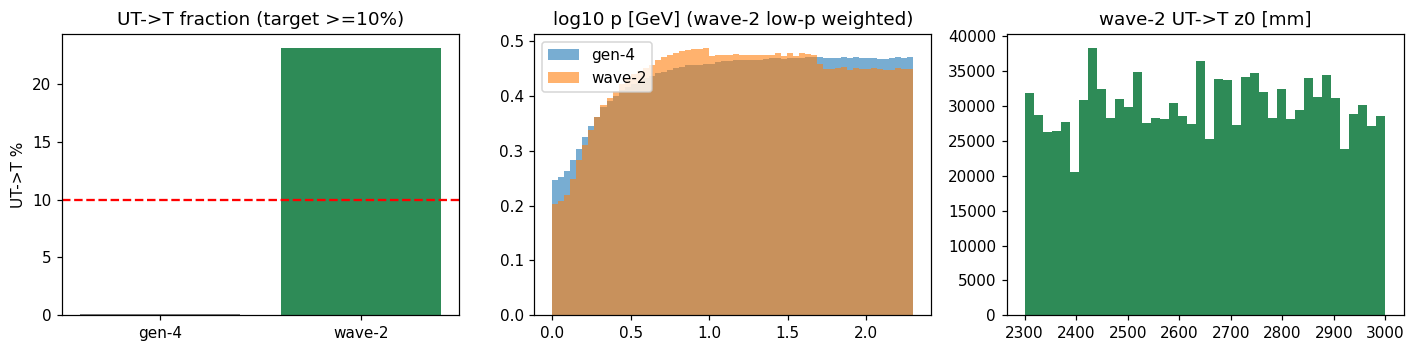

In [3]:
meta = json.load(open(DATA/"train_wave2_deploy.meta.json"))
print(json.dumps(meta, indent=1))
w = np.load(DATA/"train_wave2_deploy.npz")
Xw=w["X"]; z0=Xw[:,5]; zf=z0+Xw[:,6]
uttw=(z0>=2300)&(z0<=3000)&(zf>=7600)&(zf<=9500)&(Xw[:,6]>0)
pw=0.299792458/np.abs(Xw[:,4])
fig,ax=plt.subplots(1,3,figsize=(13,3.3))
ax[0].bar(["gen-4","wave-2"],[0.145, 100*uttw.mean()],color=['gray','seagreen'])
ax[0].set_ylabel("UT->T %"); ax[0].set_title("UT->T fraction (target >=10%)"); ax[0].axhline(10,ls='--',c='r')
ax[1].hist(np.log10(p),bins=60,alpha=.6,density=True,label='gen-4')
ax[1].hist(np.log10(pw),bins=60,alpha=.6,density=True,label='wave-2'); ax[1].legend()
ax[1].set_title("log10 p [GeV] (wave-2 low-p weighted)")
ax[2].hist(Xw[uttw,5],bins=40,color='seagreen'); ax[2].set_title("wave-2 UT->T z0 [mm]"); plt.tight_layout()

## 3 · Range-aware residual loss design

The legacy log-cosh divides by the **endpoint** std (x ≈ 1.2 m), so a 100 µm
error registers as ~1e-7 — only metre-scale tail tracks produce gradient. Wave-2
scales by a per-track **residual** scale `sqrt(floor² + (α·bend)²)` (floor 20 µm /
20 µrad, α=0.25), measured per component → x,y(mm) balanced against tx,ty(rad).

In [4]:
# endpoint std (legacy scale) vs residual std (what matters)
rb = np.stack([Yg[:,i]-(Xg[:,0]+Xg[:,2]*dz if i==0 else Xg[:,1]+Xg[:,3]*dz if i==1 else Xg[:,i]) for i in range(4)],1)
import numpy as np
endpoint_std = Yg[:,:4].std(0); resid_std = rb.std(0)
print("component         x[mm]    y[mm]   tx[rad]  ty[rad]")
print("endpoint std :", np.round(endpoint_std,4))
print("residual std :", np.round(resid_std,4))
print("ratio        :", np.round(endpoint_std/resid_std,1), " <- legacy over-scales x the most")

component         x[mm]    y[mm]   tx[rad]  ty[rad]
endpoint std : [1.1668013e+03 9.6162659e+02 2.1750000e-01 1.4219999e-01]
residual std : [2.42921e+02 1.84620e+01 7.99000e-02 6.80000e-03]
ratio        : [ 4.8 52.1  2.7 20.8]  <- legacy over-scales x the most


## 4 · Wave-2 training: capacity ladder + λ sweep

run                     h best_ep  utt_med_um bulk_med_mm  epochs
wave2_resid_h32        32     107      3832.3      1.0847     120
wave2_resid_h64        64      94      3299.7      1.0097     120
wave2_resid_h96        96     102      3195.7      0.9996     120
wave2_resid_h128      128      90      3161.9       0.989     120
wave2_resid_h256      256      82      3108.7      0.9963     120
wave2_resid_h384      384      91      3130.4      0.9705     120


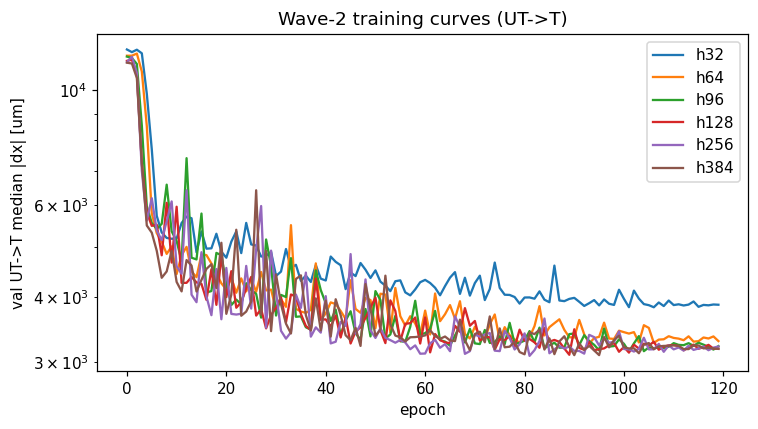

In [5]:
def load_hist(name):
    h=TM/name/"history.json"
    return json.load(open(h)) if h.exists() else None
sizes=[("wave2_resid_h%d"%h, h) for h in (32,64,96,128,256,384)]
rows=[]
for name,h in sizes:
    H=load_hist(name)
    if not H: continue
    tf=H.get("test_final",{}); bf=H.get("best_val_full",{})
    npar=None
    try: npar=json.load(open(TM/name/"config.json")) and None
    except: pass
    rows.append((name,h,H.get("best_epoch"),tf.get("utt_median_dx_um"),tf.get("median_dx_mm"),len(H.get("val",[]))))
print(f"{'run':<20}{'h':>5}{'best_ep':>8}{'utt_med_um':>12}{'bulk_med_mm':>12}{'epochs':>8}")
for r in rows: print(f"{r[0]:<20}{r[1]:>5}{str(r[2]):>8}{str(round(r[3],1) if r[3]==r[3] else r[3]):>12}{str(round(r[4],4)):>12}{r[5]:>8}")
# training curves
fig,ax=plt.subplots(figsize=(7,4))
for name,h in sizes:
    H=load_hist(name)
    if not H: continue
    u=[v.get("utt_median_dx_um",np.nan) for v in H["val"]]
    ax.plot(u,label="h%d"%h)
ax.set_yscale('log'); ax.set_xlabel("epoch"); ax.set_ylabel("val UT->T median |dx| [um]")
ax.legend(); ax.set_title("Wave-2 training curves (UT->T)"); plt.tight_layout()

## 5 · Three-arm evaluation vs the incumbent (plane ref)

Incumbent profile to beat: **median 11 µm · low-p quartile 475 µm · p95 1.6 mm**.

In [6]:
res=json.load(open(REF/"wave2_three_arm.json"))
print(f"{'arm':<26}{'med um':>9}{'p95 um':>10}{'specMed':>9}  byQ hi->lo p [um]")
for k,m in res.items():
    bq="/".join(f"{v:.0f}" for v in m["median_dx_um_by_qop_quartile_hi2lo_p"])
    print(f"{k:<26}{m['median_dx_um']:>9.1f}{m['p95_dx_um']:>10.1f}{m['spec_weighted_median_dx_um']:>9.1f}  [{bq}]")

arm                          med um    p95 um  specMed  byQ hi->lo p [um]
extrapUTT (incumbent)          10.9    1604.6    247.4  [2/3/27/475]
straight_line              225343.2 1416076.9 818253.4  [52976/143064/364683/1008979]
pinn_v2_g4_lam0_10M        181138.1 1228311.3 658578.7  [43155/114275/292539/832395]
pinn_v2_g4_lam0p1_10M      219930.4 1358057.4 775490.6  [51898/141001/350659/961598]
wave2_lam0p01_h128           3633.5   27818.0   9752.1  [953/2580/6244/14122]
wave2_lam0p1_h128            3487.9   25702.4   9185.4  [934/2492/5839/13437]
wave2_resid_h128             3032.1   25103.6   8188.8  [817/2188/5207/12139]
wave2_resid_h256             3477.3   23165.7   9060.1  [937/2503/5885/12777]
wave2_resid_h32              2806.8   29730.8   8222.7  [823/2294/5446/12725]
wave2_resid_h384             3782.3   22537.2   9037.5  [1014/2732/6474/12362]
wave2_resid_h64              2788.6   23578.5   7801.7  [777/2091/5038/11333]
wave2_resid_h96              3580.8   23412.9   9400.6

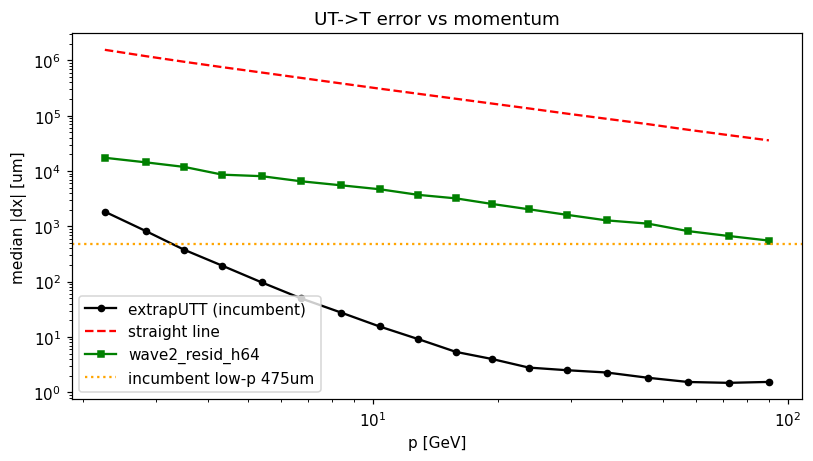

In [7]:
# error vs p: incumbent vs best wave-2 NN vs straight line
A=np.load(REF/"wave2_three_arm_arrays.npz")
p=A["p_GeV"]; order=np.argsort(p)
nn = [k for k in A.files if k.startswith("wave2_")]
best = min(nn, key=lambda k: np.median(A[k])) if nn else None
def binned(p,dx,nb=18):
    e=np.quantile(p,np.linspace(0,1,nb+1)); c=0.5*(e[1:]+e[:-1])
    m=[np.median(dx[(p>=e[i])&(p<e[i+1])]) for i in range(nb)]; return c,m
fig,ax=plt.subplots(figsize=(7.5,4.3))
for key,lab,st in [("extrapUTT","extrapUTT (incumbent)",'k-o'),("straight_line","straight line",'r--'),(best,best,'g-s')]:
    if key is None or key not in A.files: continue
    c,m=binned(p,A[key]); ax.plot(c,m,st,label=lab,ms=4)
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlabel("p [GeV]"); ax.set_ylabel("median |dx| [um]")
ax.axhline(475,ls=':',c='orange',label='incumbent low-p 475um'); ax.legend(); ax.set_title("UT->T error vs momentum"); plt.tight_layout()

## 6 · Accuracy ↔ size curve (the capacity question)

wave2_resid_h32      params=   1416  med=  2806.8um  specMed=  8222.7um
wave2_resid_h64      params=   4872  med=  2788.6um  specMed=  7801.7um
wave2_resid_h96      params=  10376  med=  3580.8um  specMed=  9400.6um
wave2_resid_h128     params=  17928  med=  3032.1um  specMed=  8188.8um
wave2_resid_h256     params=  68616  med=  3477.3um  specMed=  9060.1um
wave2_resid_h384     params= 152072  med=  3782.3um  specMed=  9037.5um


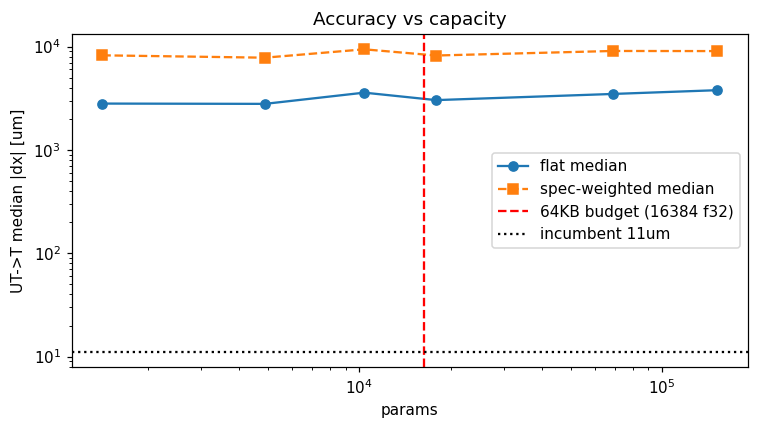

In [8]:
# UT->T median on the plane ref vs parameter count, with the 64KB Allen budget line
res=json.load(open(REF/"wave2_three_arm.json"))
pts=[]
for k,m in res.items():
    if k.startswith("wave2_resid_h") and "params" in m:
        pts.append((m["params"], m["median_dx_um"], m["spec_weighted_median_dx_um"], k))
pts.sort()
if pts:
    par=[p[0] for p in pts]; med=[p[1] for p in pts]; sm=[p[2] for p in pts]
    fig,ax=plt.subplots(figsize=(7,4))
    ax.plot(par,med,'o-',label='flat median'); ax.plot(par,sm,'s--',label='spec-weighted median')
    ax.axvline(16384,c='r',ls='--',label='64KB budget (16384 f32)')
    ax.axhline(11,c='k',ls=':',label='incumbent 11um')
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlabel("params"); ax.set_ylabel("UT->T median |dx| [um]")
    ax.legend(); ax.set_title("Accuracy vs capacity"); plt.tight_layout()
    for p_,m_,s_,k_ in pts: print(f"{k_:<20} params={p_:>7}  med={m_:8.1f}um  specMed={s_:8.1f}um")

## 7 · Frozen UT→T pool (sanity gate: beat straight line ≥10×)

In [9]:
fp=json.load(open(REF/"wave2_frozen_pool.json"))
sl=fp["straight_line"]["median_dx_um"]
print(f"straight-line median = {sl:.0f} um")
print(f"{'arm':<22}{'med um':>10}{'x vs SL':>10}")
for k,m in fp.items():
    if k=="straight_line": continue
    print(f"{k:<22}{m['median_dx_um']:>10.1f}{sl/m['median_dx_um']:>9.1f}x")

straight-line median = 205528 um
arm                       med um   x vs SL
pinn_v2_g4_lam0_10M     174346.2      1.2x
pinn_v2_g4_lam0p1_10M   205879.9      1.0x
wave2_lam0p01_h128        4350.3     47.2x
wave2_lam0p1_h128         4119.8     49.9x
wave2_resid_h128          4292.5     47.9x
wave2_resid_h256          4271.1     48.1x
wave2_resid_h32           5460.6     37.6x
wave2_resid_h384          4318.1     47.6x
wave2_resid_h64           4540.5     45.3x
wave2_resid_h96           4312.3     47.7x


## 8 · Verdict

*(filled from the numbers above — see the Notion write-up for the decision.)*